# GMM Weekly Cluster Profiling

Profile `dev_gmm_weekly_clusters_v1` against `dev_weekly_features_v2` to assign business-friendly names to weekly GMM clusters **0, 1, 2**.

**Note:** This is separate from HMM hidden states and from explicit missing weeks (`-1` in categorical HMM gap-filling).

Runs locally or in Colab (Drive parquets + optional DuckDB).


## 1) Colab setup (optional)


In [1]:
# from google.colab import drive
# drive.mount('/content/drive')
# PROJECT_DIR = "/content/drive/MyDrive/NVIDIA Industry Project"
PROJECT_DIR = "."
print("PROJECT_DIR:", PROJECT_DIR)


PROJECT_DIR: .


In [2]:
# !pip install duckdb pandas numpy matplotlib pyarrow


In [3]:
from pathlib import Path
import warnings

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

PROJECT_DIR = Path(PROJECT_DIR)
DB_PATH = PROJECT_DIR / "developer_project.duckdb"
PARQUET_DIR = PROJECT_DIR
OUTPUT_DIR = PROJECT_DIR / "outputs" / "gmm_weekly_cluster_profiling"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GMM_TABLE = "dev_gmm_weekly_clusters_v1"
WEEKLY_TABLE = "dev_weekly_features_v2"
V11_TABLE = "dev_lifecycle_cluster_membership_v11_final"

print("OUTPUT_DIR:", OUTPUT_DIR.resolve())


OUTPUT_DIR: /Users/pmazolew/Documents/GitHub/Spring2026_IndustryProject/outputs/gmm_weekly_cluster_profiling


## 2) Connect and load tables


In [4]:
con = duckdb.connect(str(DB_PATH))


def table_exists(name: str) -> bool:
    return con.execute(
        "SELECT COUNT(*) FROM information_schema.tables "
        "WHERE table_schema='main' AND table_name='" + name + "'"
    ).fetchone()[0] > 0


def load_parquet(table: str) -> None:
    path = PARQUET_DIR / f"{table}.parquet"
    if not path.exists():
        raise FileNotFoundError(path)
    sql = (
        "CREATE OR REPLACE TABLE " + table + " AS "
        "SELECT * FROM read_parquet('" + path.as_posix() + "')"
    )
    con.execute(sql)
    print("Loaded", path.name)


for t in [GMM_TABLE, WEEKLY_TABLE]:
    if not table_exists(t):
        load_parquet(t)

if not table_exists(V11_TABLE):
    v11_path = PARQUET_DIR / f"{V11_TABLE}.parquet"
    if v11_path.exists():
        load_parquet(V11_TABLE)
    else:
        print("V11 final table not found; stratum breakdown will be skipped.")

print("Tables ready.")


Tables ready.


## 3) Join GMM weekly assignments to weekly features (SQL aggregates)


In [5]:
con.execute("""
CREATE OR REPLACE TEMP TABLE gmm_weekly_profile_base AS
SELECT
    g.developer_id,
    CAST(g.week_start AS DATE) AS week_start,
    CAST(g.gmm_weekly_cluster_id AS INTEGER) AS gmm_weekly_cluster_id,
    CAST(g.gmm_weekly_max_posterior AS DOUBLE) AS gmm_weekly_max_posterior,
    CAST(g.gmm_weekly_prob_c0 AS DOUBLE) AS gmm_weekly_prob_c0,
    CAST(g.gmm_weekly_prob_c1 AS DOUBLE) AS gmm_weekly_prob_c1,
    CAST(g.gmm_weekly_prob_c2 AS DOUBLE) AS gmm_weekly_prob_c2,
    CAST(w.activity_count_total AS DOUBLE) AS activity_count_total,
    CAST(w.activity_score_sum AS DOUBLE) AS activity_score_sum,
    CAST(w.unique_activity_types AS DOUBLE) AS unique_activity_types,
    CAST(w.build_count AS DOUBLE) AS build_count,
    CAST(w.champion_count AS DOUBLE) AS champion_count,
    CAST(w.high_effort_count AS DOUBLE) AS high_effort_count,
    CAST(w.product_use_count AS DOUBLE) AS product_use_count
FROM dev_gmm_weekly_clusters_v1 g
INNER JOIN dev_weekly_features_v2 w
  ON CAST(g.developer_id AS VARCHAR) = CAST(w.developer_id AS VARCHAR)
 AND CAST(g.week_start AS DATE) = CAST(w.week_start AS DATE)
""")

overview = con.execute("""
SELECT
    COUNT(*) AS joined_week_rows,
    COUNT(DISTINCT developer_id) AS developers,
    MIN(week_start) AS min_week,
    MAX(week_start) AS max_week,
    COUNT(DISTINCT gmm_weekly_cluster_id) AS n_gmm_clusters
FROM gmm_weekly_profile_base
""").fetchdf()
display(overview)

gmm_only = con.execute("""
SELECT
    gmm_weekly_cluster_id,
    COUNT(*) AS n_weeks,
    COUNT(DISTINCT developer_id) AS n_developers,
    AVG(gmm_weekly_max_posterior) AS avg_posterior,
    MEDIAN(gmm_weekly_max_posterior) AS med_posterior
FROM gmm_weekly_profile_base
GROUP BY 1
ORDER BY 1
""").fetchdf()
display(gmm_only)


,joined_week_rows,developers,min_week,max_week,n_gmm_clusters
0,14908480,7660278,2019-12-30,2026-03-09,3


,gmm_weekly_cluster_id,n_weeks,n_developers,avg_posterior,med_posterior
0,0,8992453,4302668,0.999994,0.999999
1,1,382890,177375,0.996337,1.000000
2,2,5533137,4965049,0.999726,1.000000


## 4) Cluster behavioral profiles (mean + median)


In [6]:
profile_mean = con.execute("""
SELECT
    gmm_weekly_cluster_id,
    COUNT(*) AS n_weeks,
    COUNT(DISTINCT developer_id) AS n_developers,
    AVG(gmm_weekly_max_posterior) AS avg_posterior,
    AVG(activity_count_total) AS avg_activity_count,
    MEDIAN(activity_count_total) AS med_activity_count,
    AVG(activity_score_sum) AS avg_activity_score,
    MEDIAN(activity_score_sum) AS med_activity_score,
    AVG(unique_activity_types) AS avg_unique_types,
    AVG(build_count) AS avg_build_count,
    AVG(champion_count) AS avg_champion_count,
    AVG(high_effort_count) AS avg_high_effort_count,
    AVG(product_use_count) AS avg_product_use_count,
    AVG(CASE WHEN activity_count_total = 0 THEN 1.0 ELSE 0.0 END) AS pct_zero_activity_weeks,
    AVG(build_count / NULLIF(activity_count_total, 0)) AS avg_build_share,
    AVG(high_effort_count / NULLIF(activity_count_total, 0)) AS avg_high_effort_share,
    AVG(product_use_count / NULLIF(activity_count_total, 0)) AS avg_product_use_share
FROM gmm_weekly_profile_base
GROUP BY 1
ORDER BY 1
""").fetchdf()

display(profile_mean)
profile_mean.to_csv(OUTPUT_DIR / "gmm_weekly_cluster_profile_mean.csv", index=False)


,gmm_weekly_cluster_id,n_weeks,n_developers,avg_posterior,avg_activity_count,med_activity_count,avg_activity_score,med_activity_score,avg_unique_types,avg_build_count,avg_champion_count,avg_high_effort_count,avg_product_use_count,pct_zero_activity_weeks,avg_build_share,avg_high_effort_share,avg_product_use_share
0,0,8992453,4302668,0.999994,4.356605,1.0,12.954934,3.0,1.000000,2.479379,0.000000,0.0,0.000000,0.0,0.288674,0.0,0.000000
1,1,382890,177375,0.996337,33.762005,4.0,122.168753,14.0,1.617180,26.480357,3.385192,0.0,0.318162,0.0,0.349919,0.0,0.063503
2,2,5533137,4965049,0.999726,3.116460,2.0,13.593028,7.0,2.165518,0.716258,0.000000,0.0,0.000000,0.0,0.226732,0.0,0.000000


## 5) Heatmap (z-scored feature means)


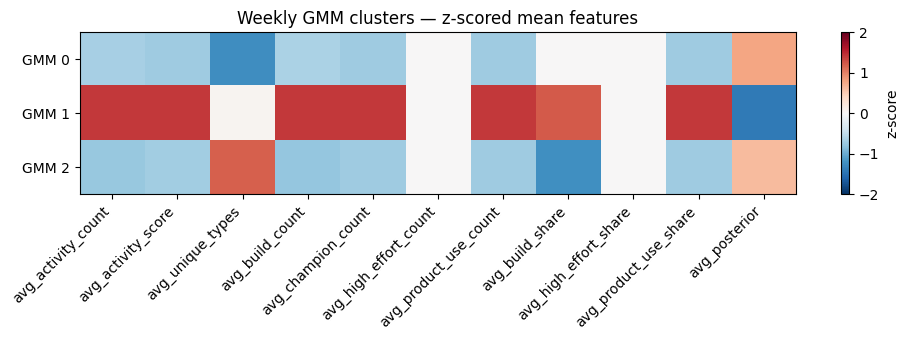

In [7]:
feature_cols = [
    "avg_activity_count",
    "avg_activity_score",
    "avg_unique_types",
    "avg_build_count",
    "avg_champion_count",
    "avg_high_effort_count",
    "avg_product_use_count",
    "avg_build_share",
    "avg_high_effort_share",
    "avg_product_use_share",
    "avg_posterior",
]

heat = profile_mean.set_index("gmm_weekly_cluster_id")[feature_cols].astype(float)
heat_z = (heat - heat.mean()) / heat.std(ddof=0).replace(0, np.nan)
heat_z = heat_z.fillna(0.0)

fig, ax = plt.subplots(figsize=(10, 3.5))
im = ax.imshow(heat_z.values, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha="right")
ax.set_yticks(range(len(heat_z)))
ax.set_yticklabels([f"GMM {i}" for i in heat_z.index])
ax.set_title("Weekly GMM clusters — z-scored mean features")
plt.colorbar(im, ax=ax, label="z-score")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gmm_weekly_cluster_feature_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

heat_z.to_csv(OUTPUT_DIR / "gmm_weekly_cluster_feature_heatmap_z.csv")


## 6) GMM cluster mix by lifecycle stratum (optional)


In [9]:
if table_exists(V11_TABLE):
    mix = con.execute(f'''
    SELECT
        c.stratum,
        b.gmm_weekly_cluster_id,
        COUNT(*) AS n_weeks,
        COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY c.stratum) AS share_within_stratum
    FROM gmm_weekly_profile_base b
    INNER JOIN {V11_TABLE} c
      ON CAST(b.developer_id AS VARCHAR) = CAST(c.developer_id AS VARCHAR)
    WHERE lower(c.stratum) IN ('active', 'cooling', 'at_risk')
    GROUP BY 1, 2
    ORDER BY 1, 2
    ''').fetchdf()
    display(mix.pivot(index="stratum", columns="gmm_weekly_cluster_id", values="share_within_stratum").round(3))
    mix.to_csv(OUTPUT_DIR / "gmm_weekly_cluster_by_stratum.csv", index=False)
else:
    print("Skipping stratum mix — V11 final table not available.")


gmm_weekly_cluster_id,0,1,2
stratum,,,
active,0.786,0.054,0.160
at_risk,0.649,0.027,0.324
cooling,0.719,0.040,0.240


## 7) Suggested provisional names (edit after review)


In [10]:
rank_df = profile_mean.copy()
rank_df["intensity_score"] = (
    rank_df["avg_activity_count"].rank(pct=True)
    + rank_df["avg_activity_score"].rank(pct=True)
    + rank_df["avg_high_effort_count"].rank(pct=True)
    + rank_df["avg_build_count"].rank(pct=True)
)
rank_df = rank_df.sort_values("intensity_score")

name_map = {}
ordered = rank_df["gmm_weekly_cluster_id"].tolist()
if len(ordered) == 3:
    name_map[ordered[0]] = "light_active_week"
    name_map[ordered[1]] = "moderate_active_week"
    name_map[ordered[2]] = "high_intensity_week"
else:
    for i, cid in enumerate(ordered):
        name_map[cid] = f"gmm_cluster_{cid}"

suggestions = profile_mean.copy()
suggestions["provisional_name"] = suggestions["gmm_weekly_cluster_id"].map(name_map)
suggestions["intensity_rank"] = suggestions["gmm_weekly_cluster_id"].map(
    {cid: i + 1 for i, cid in enumerate(ordered)}
)

display(suggestions[[
    "gmm_weekly_cluster_id",
    "provisional_name",
    "intensity_rank",
    "n_weeks",
    "avg_activity_count",
    "avg_activity_score",
    "avg_build_count",
    "avg_high_effort_count",
    "pct_zero_activity_weeks",
    "avg_posterior",
]])

suggestions.to_csv(OUTPUT_DIR / "gmm_weekly_cluster_name_suggestions.csv", index=False)
print("Saved outputs to", OUTPUT_DIR.resolve())


,gmm_weekly_cluster_id,provisional_name,intensity_rank,n_weeks,avg_activity_count,avg_activity_score,avg_build_count,avg_high_effort_count,pct_zero_activity_weeks,avg_posterior
0,0,moderate_active_week,2,8992453,4.356605,12.954934,2.479379,0.0,0.0,0.999994
1,1,high_intensity_week,3,382890,33.762005,122.168753,26.480357,0.0,0.0,0.996337
2,2,light_active_week,1,5533137,3.116460,13.593028,0.716258,0.0,0.0,0.999726


Saved outputs to /Users/pmazolew/Documents/GitHub/Spring2026_IndustryProject/outputs/gmm_weekly_cluster_profiling


## 8) Notes for interpretation

- **GMM clusters** apply only to developer-weeks present in `dev_gmm_weekly_clusters_v1` (observed weekly rows).
- **Missing/no-activity weeks** in categorical HMM are a separate explicit category (`-1`), not GMM cluster 2 by default.
- Revisit `provisional_name` after reviewing heatmap and stratum mix; rename in HMM README/notebooks as needed.


In [ ]:
# con.close()  # optional
